<p><img alt="UdeA logo" height="250px" src="https://upload.wikimedia.org/wikipedia/commons/f/fb/Escudo-UdeA.svg" align="left" hspace="10px" ></p>

<h1><b>Practice 2 - Radiation statistics - Experimental Physics IV<b></h1>
<div align="left+">
<h2><b>Institute of Physics<b></h2>

<font size=3>
Estiven Castrillon - estiven.castrillon2@udea.edu.co<br>
Ana Sofía Mora - ana.mora@udea.edu.co<br>
Sebastián Duque - sebastian.duque6@udea.edu.co<br>
Alejandro Arboleda - dalejandro.arboleda1@udea.edu.co<br>
</font>
</div>

## Introduction

The detection of ionizing radiation is fundamental in multiple areas of experimental physics, medicine, and industry. Among the most widely used devices for this purpose are scintillation detectors coupled to photomultiplier tubes, due to their high sensitivity and ability to detect individual radiation events. These systems allow the energy deposited by radiation to be transformed into measurable electrical signals, facilitating numerical analysis of the interaction processes between radiation and matter.

In this experiment, a scintillation tube was used, which combines a scintillating material with a photomultiplier tube (PMT), to detect high-energy radiation. The scintillating material emits visible light in the form of discrete pulses when excited by incident radiation. These light pulses are converted into electrical signals by the PMT, where the photoelectric effect and secondary electron multiplication in the dynodes allow amplification of the original signal to detectable levels. Additionally, a similar device constructed with Arduino was used.

The primary objective of the experiment was to study the radiation detection process using a scintillator-photomultiplier system, as well as analyze the statistical nature of detected event counting. Since the processes involved are random and independent, the distribution of the number of recorded events is expected to follow Poisson statistics.

# Theoretical framework

A scintillation tube generally consists of a scintillating material and a photodetector (a photomultiplier tube is commonly used). Scintillating materials are substances that transform the energy transmitted by high-energy radiation (such as X-rays or gamma rays) into visible light. This process occurs because radiation excites atoms in the scintillating material, which subsequently return to their ground state by emitting photons. The scintillating material can be solid, liquid, or gaseous, as well as organic or inorganic.

Photomultiplier tubes (PMT) consist of a photocathode followed by a chain of dynodes and an anode. They function such that when a photon from the scintillator strikes the photocathode, it emits a photoelectron through the photoelectric effect. This electron is accelerated to the first dynode where it produces the emission of several secondary electrons. This process repeats over and over along the row of dynodes, which generates amplification of the initial signal. Finally, the electrons reach the anode, where the resulting signal is collected. [1]

The light emitted by the scintillating material is produced in the form of discrete pulses, which can be detected by the photomultiplier tube. Each point of light that strikes the PMT generates a set of photoelectrons that, after the amplification process in the dynodes, results in a charge pulse at the anode. These pulses can be subsequently analyzed or counted using electronic devices. Because scintillations correspond to individual detection events and the random nature of the radiation interaction processes with the scintillator and photoelectron emission, event counting exhibits statistical fluctuation that corresponds to the Poisson distribution. [2]

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import factorial

# Plotting style
sns.set_theme(context='paper', style='whitegrid', font='serif', font_scale=1.2)
plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.fancybox": False,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.visible": True,
    "xtick.minor.visible": True,
    "figure.dpi": 150,
})

In [13]:
# Data
df = pd.read_excel('data/datos.xlsx')
print('Data:')
display(df.head(2))

# Rename columns
df.columns = [
    "times_5_particles_arduino_ms",
    "particles_detected_thorium_arduino",
    "particles_detected_background_arduino",
    "times_5_particles_s",
    "particles_detected_background_machine",
    "particles_detected_thorium_machine"
]

# Convert to numeric and remove NaN individually (data separation so each has its own cleaning)
times_arduino_ms = pd.to_numeric(df["times_5_particles_arduino_ms"], errors='coerce').dropna()
thorium_arduino = pd.to_numeric(df["particles_detected_thorium_arduino"], errors='coerce').dropna().astype(int)
background_arduino = pd.to_numeric(df["particles_detected_background_arduino"], errors='coerce').dropna().astype(int)

times_machine_s = pd.to_numeric(df["times_5_particles_s"], errors='coerce').dropna()
background_machine = pd.to_numeric(df["particles_detected_background_machine"], errors='coerce').dropna().astype(int)
thorium_machine = pd.to_numeric(df["particles_detected_thorium_machine"], errors='coerce').dropna().astype(int)

# Convert milliseconds to seconds for Arduino
times_arduino_s = times_arduino_ms / 1000.0

print(f"n times Arduino: {len(times_arduino_s)}")
print(f"n background Arduino: {len(background_arduino)}")
print(f"n thorium Arduino: {len(thorium_arduino)}")
print(f"n times Machine: {len(times_machine_s)}")
print(f"n background Machine: {len(background_machine)}")
print(f"n thorium Machine: {len(thorium_machine)}")

Data:


,tiempos_5_particulas_arduino(ms),particulas_detectadas_torio_arduino,particulas_detectadas_ambiente_arduino,tiempos_5_particulas(s),particulas_detectadas_ambiente_maquina,particulas_detectadas_torio_maquina
0,19039.0,33.0,0.0,7.13,5,10.0
1,33466.0,23.0,0.0,7.46,4,10.0


n times Arduino: 9
n background Arduino: 34
n thorium Arduino: 14
n times Machine: 30
n background Machine: 36
n thorium Machine: 30


In [14]:
average_time_arduino = times_arduino_s.mean() if len(times_arduino_s) > 0 else np.nan
average_time_machine = times_machine_s.mean() if len(times_machine_s) > 0 else np.nan

print(f"Average time Arduino (5 counts): {average_time_arduino:.2f} s")
print(f"Average time Machine (5 counts): {average_time_machine:.2f} s")

Average time Arduino (5 counts): 22.74 s
Average time Machine (5 counts): 9.63 s


In [15]:
def chi_squared(observed: np.ndarray, expected: np.ndarray) -> np.float64:
    """
    Function that calculates the chi-squared statistic, which is used to evaluate the goodness of fit of a model.
    
    Parameters:
    observed : np.ndarray
        Observed frequencies.
    expected : np.ndarray
        Expected frequencies.
    
    Returns:
    float
        Chi-squared statistic.
    """
    mask = expected > 0
    observed = observed[mask]
    expected = expected[mask]
    chi2 = np.sum((observed - expected) ** 2 / expected)
    return chi2


from matplotlib import axes
from scipy.stats import chi2 as chi2_dist
import math

def analysis(data: pd.Series, title: str, color: str, ax: axes.Axes, rotation: int = 0) -> None:
    """
    Performs analysis of experimental data, fits a Poisson distribution,
    calculates the chi-squared statistic and p-value, and generates a plot with results.
    """
    lambda_data = np.mean(data)
    max_k = data.max()
    min_k = data.min()

    # Observed frequencies
    values_k, observed = np.unique(data, return_counts=True)

    # Manual definition of the Poisson distribution
    def poisson_manual(k, lam):
        return (math.exp(-lam) * (lam ** k)) / math.factorial(k)

    # Calculation of expected frequencies using the formula
    expected = np.array([poisson_manual(k, lambda_data) * len(data) for k in values_k])

    # Chi-squared and p-value
    chi2 = chi_squared(observed, expected)
    degrees_freedom = len(values_k) - 1 - 1
    p_value = 1 - chi2_dist.cdf(chi2, degrees_freedom) if degrees_freedom > 0 else np.nan

    # Plot
    bins = np.arange(min_k - 0.5, max_k + 1.5, 1)
    ax.hist(
        data,
        bins=bins,
        alpha=0.6,
        color=color,
        edgecolor="black",
        linewidth=1.1,
        label=f"Data from {title}"
    )

    ax.plot(
        values_k,
        expected,
        marker="o",
        markersize=6,
        linestyle="-",
        color="black",
        linewidth=1.3,
        label=f"Poisson fit (λ = {lambda_data:.2f})"
    )

    from matplotlib.offsetbox import AnchoredText
    text = f"χ² = {chi2:.2f}\ndf = {degrees_freedom}\np = {p_value:.3f}"
    at = AnchoredText(
        text,
        loc="upper left",
        prop=dict(size=10),
        frameon=True,
        borderpad=0.6
    )
    at.patch.set_boxstyle("round")
    at.patch.set_facecolor("white")
    at.patch.set_edgecolor("black")
    at.patch.set_alpha(0.85)
    ax.add_artist(at)

    ax.set_title(f"Distribution of particles detected in the {title}", weight="bold")
    ax.set_xlabel("Number of particles detected")
    ax.set_ylabel("Counts")
    ax.set_xlim(min_k - 0.5, max_k + 0.5)
    ax.set_xticks(np.arange(min_k, max_k + 1))

    # X-AXIS ROTATION
    ax.tick_params(axis='x', rotation=rotation)

    ax.legend(loc="upper right")

def filter_outliers(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    return series[(series >= lower_limit) & (series <= upper_limit)]

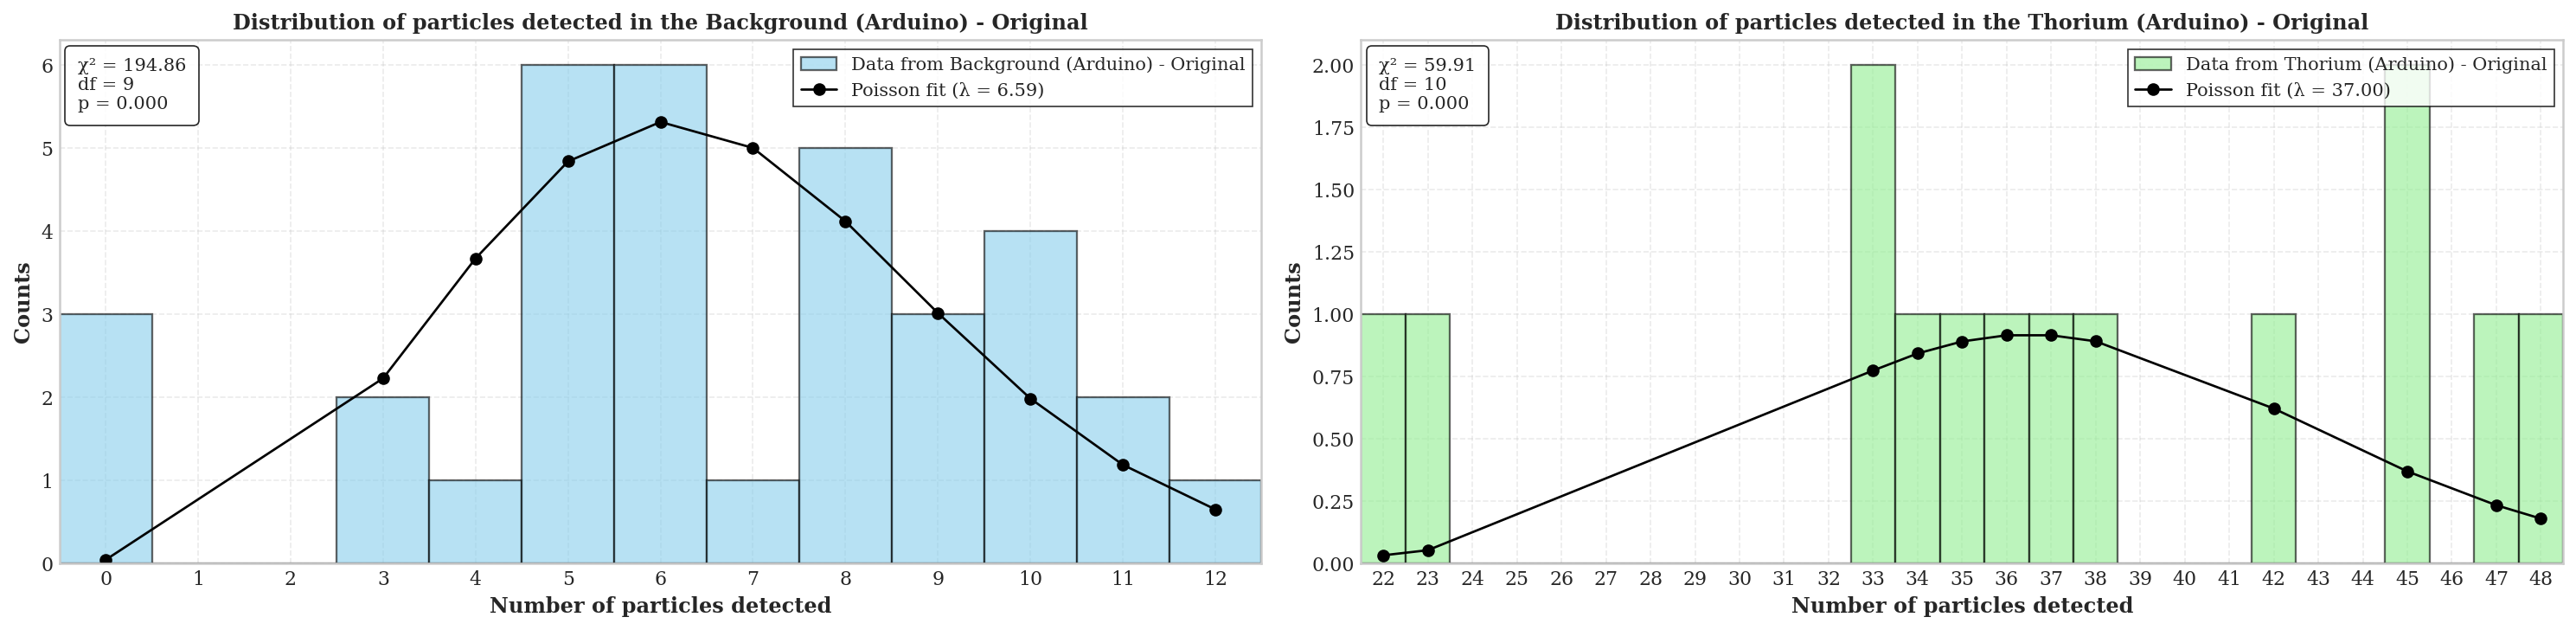

Data sizes before and after filtering outliers:
Background Arduino: 34 -> 34
Thorium Arduino: 14 -> 14
No outliers were removed, no additional plots are generated.


In [16]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
analysis(background_arduino, 'Background (Arduino) - Original', 'skyblue', axs[0])
analysis(thorium_arduino, 'Thorium (Arduino) - Original', 'lightgreen', axs[1])
plt.tight_layout()
plt.show()

background_arduino_filtered = filter_outliers(background_arduino)
thorium_arduino_filtered = filter_outliers(thorium_arduino)

print("Data sizes before and after filtering outliers:")
print(f"Background Arduino: {len(background_arduino)} -> {len(background_arduino_filtered)}")
print(f"Thorium Arduino: {len(thorium_arduino)} -> {len(thorium_arduino_filtered)}")

if len(background_arduino) != len(background_arduino_filtered) or len(thorium_arduino) != len(thorium_arduino_filtered):
    fig, axs = plt.subplots(1, 2, figsize=(20, 5))
    analysis(background_arduino_filtered, 'Background (Arduino) - Without Outliers', 'skyblue', axs[0])
    analysis(thorium_arduino_filtered, 'Thorium (Arduino) - Without Outliers', 'lightgreen', axs[1])
    plt.tight_layout()
    plt.show()
else:
    print("No outliers were removed, no additional plots are generated.")

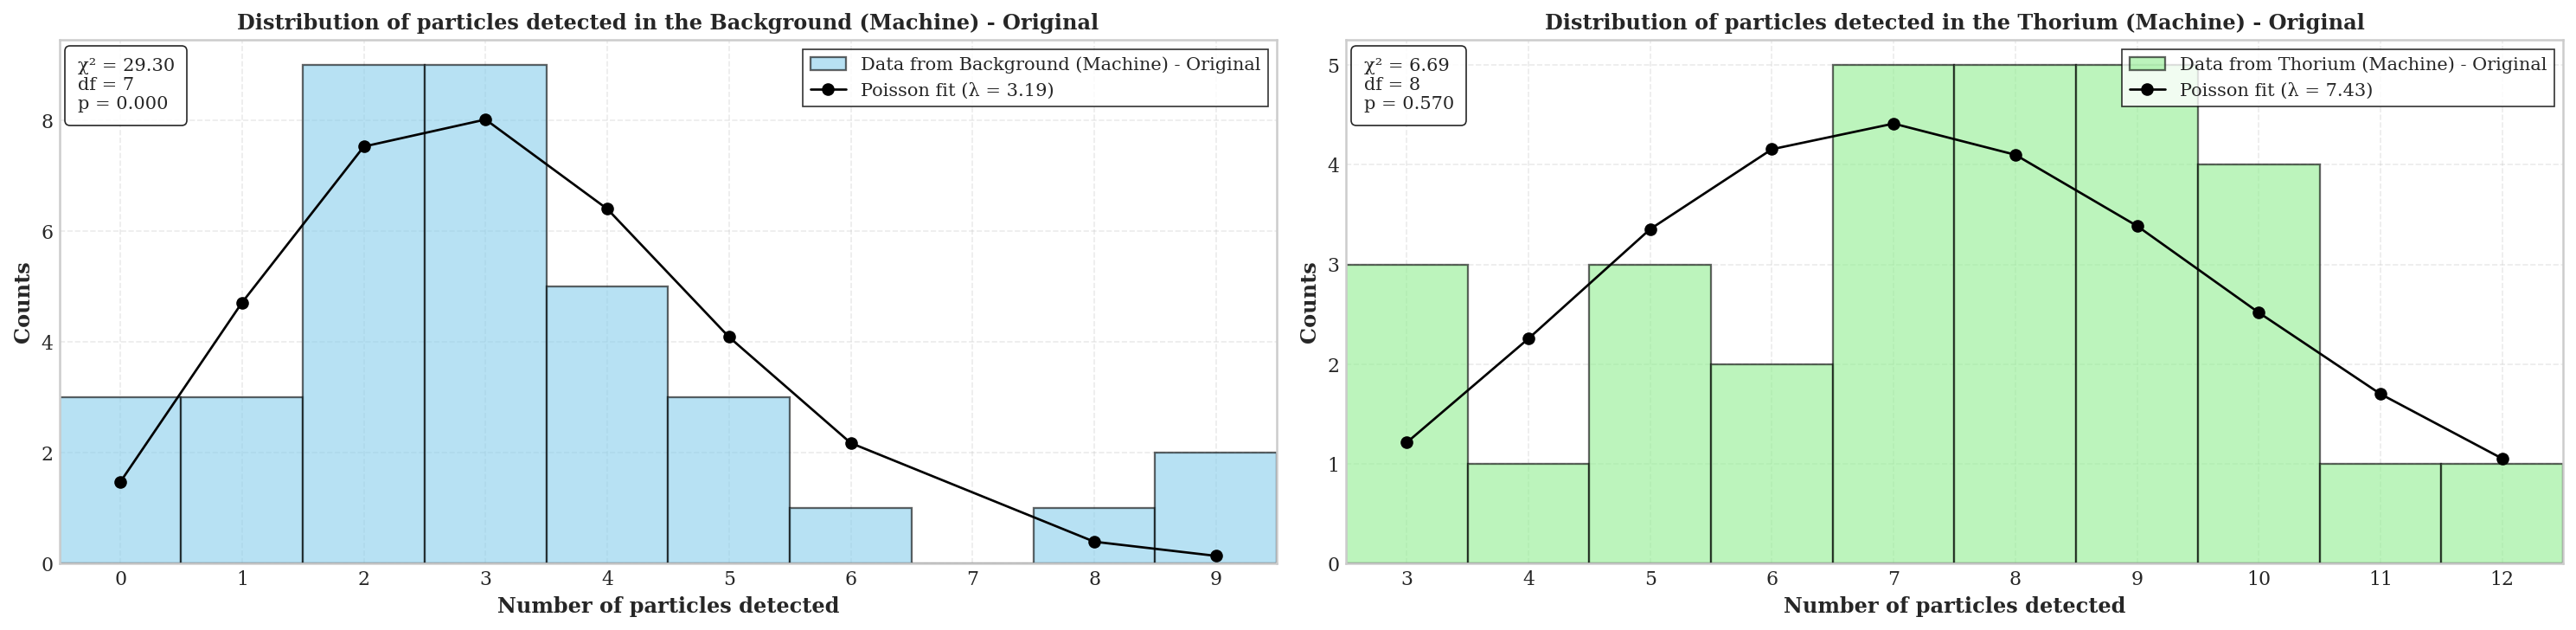

Data sizes before and after filtering outliers:
Background Machine: 36 -> 33
Thorium Machine: 30 -> 30


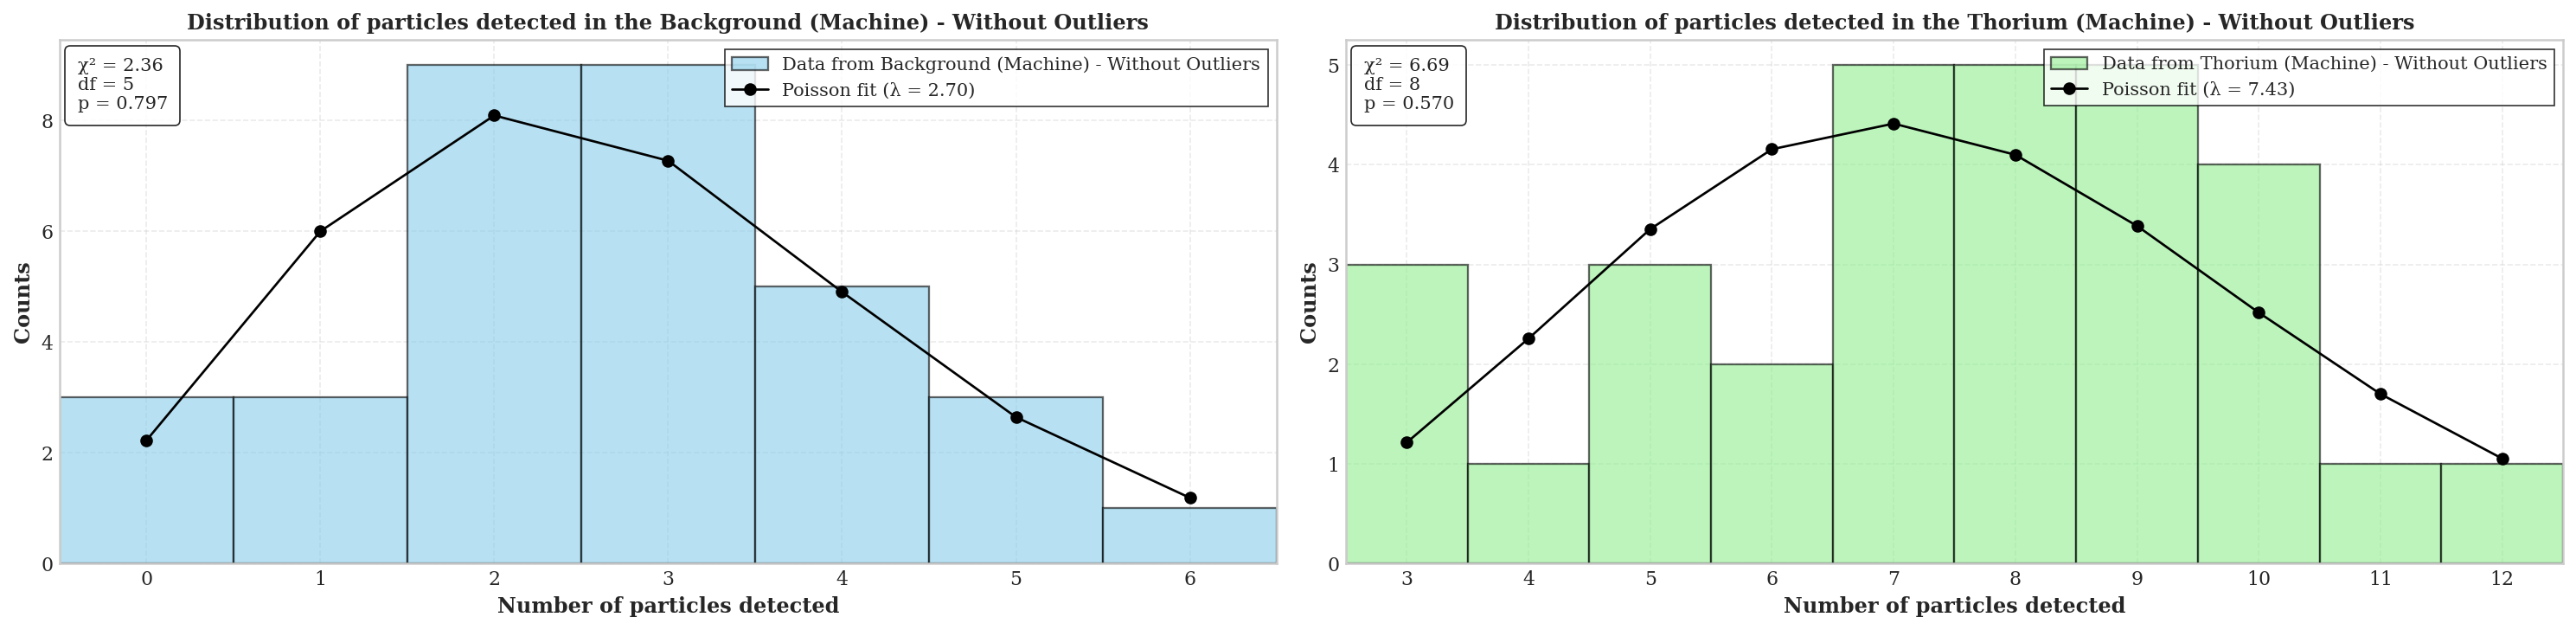

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
analysis(background_machine, 'Background (Machine) - Original', 'skyblue', axs[0])
analysis(thorium_machine, 'Thorium (Machine) - Original', 'lightgreen', axs[1])
plt.tight_layout()
plt.show()

background_machine_filtered = filter_outliers(background_machine)
thorium_machine_filtered = filter_outliers(thorium_machine)

print("Data sizes before and after filtering outliers:")
print(f"Background Machine: {len(background_machine)} -> {len(background_machine_filtered)}")
print(f"Thorium Machine: {len(thorium_machine)} -> {len(thorium_machine_filtered)}")

if len(background_machine) != len(background_machine_filtered) or len(thorium_machine) != len(thorium_machine_filtered):
    fig, axs = plt.subplots(1, 2, figsize=(20, 5))
    analysis(background_machine_filtered, 'Background (Machine) - Without Outliers', 'skyblue', axs[0])
    analysis(thorium_machine_filtered, 'Thorium (Machine) - Without Outliers', 'lightgreen', axs[1])
    plt.tight_layout()
    plt.show()
else:
    print("No outliers were removed, no additional plots are generated.")

Data sizes (without outliers):
am_0cm: 67
background: 100
th0cm: 56


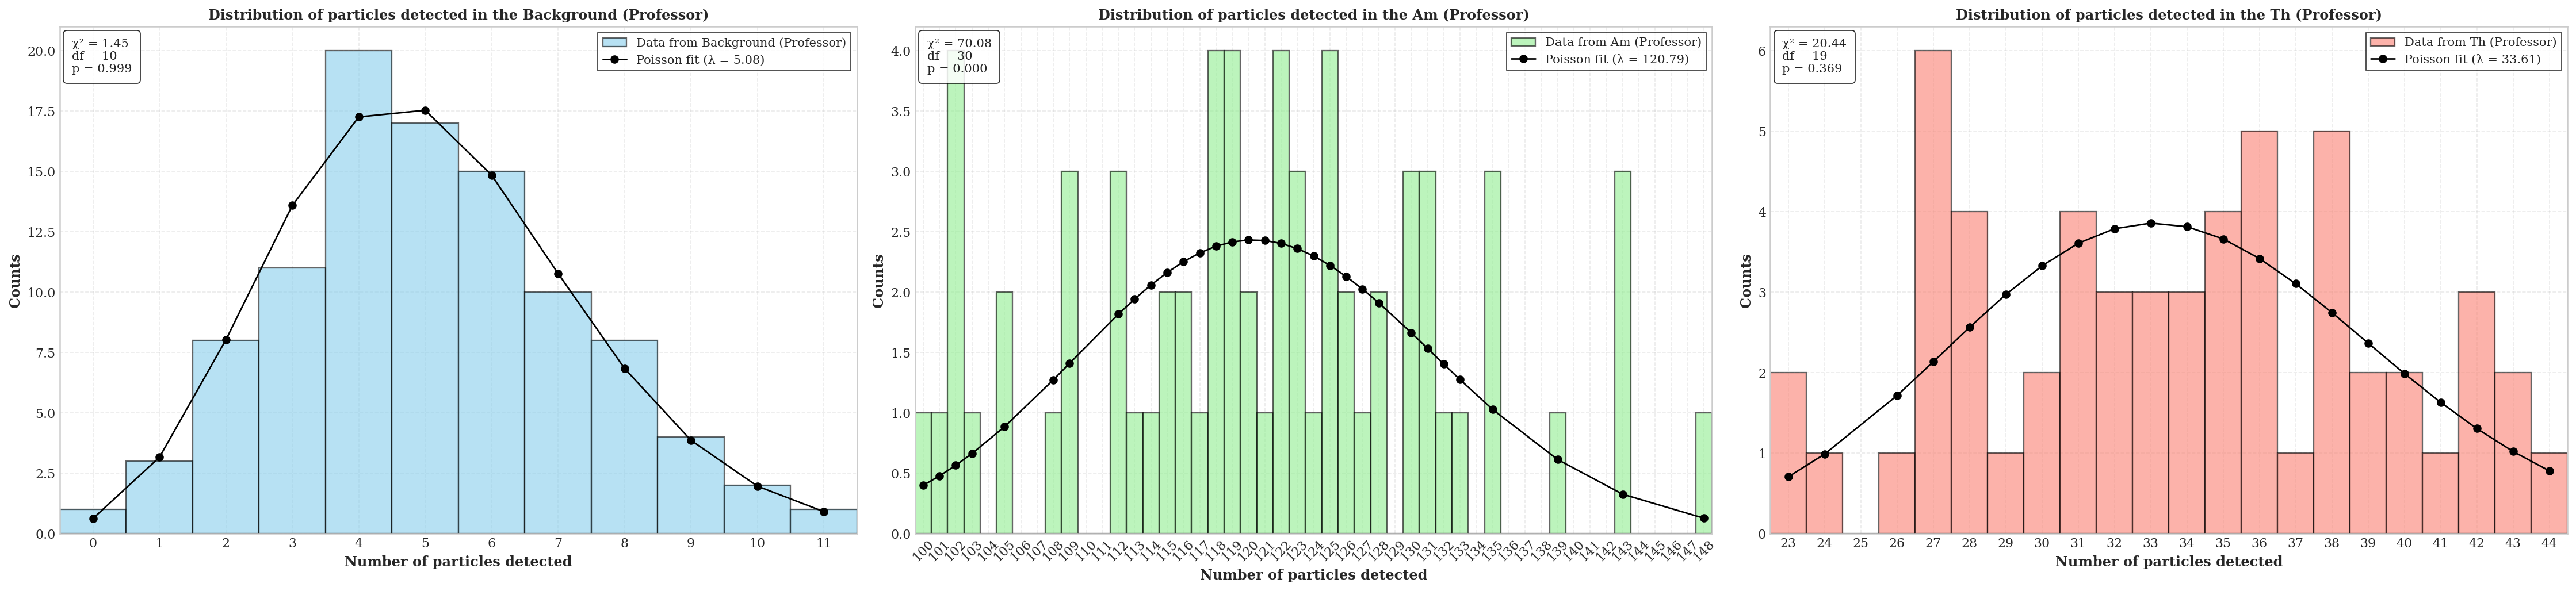

In [18]:
professor_am_data = pd.read_csv("data/am_0cm.txt", header=None).iloc[1:, 0].astype(int)
professor_background_data = pd.read_csv("data/fondo.txt", header=None).iloc[1:, 0].astype(int)
professor_th_data = pd.read_csv("data/th0cm.txt", header=None).iloc[1:, 0].astype(int)

professor_am_data = filter_outliers(professor_am_data)
professor_background_data = filter_outliers(professor_background_data)
professor_th_data = filter_outliers(professor_th_data)

print("Data sizes (without outliers):")
print(f"am_0cm: {len(professor_am_data)}")
print(f"background: {len(professor_background_data)}")
print(f"th0cm: {len(professor_th_data)}")

fig, axs = plt.subplots(1, 3, figsize=(30, 7))

analysis(professor_background_data, "Background (Professor)", "skyblue", axs[0])
analysis(professor_am_data, "Am (Professor)", "lightgreen", axs[1], rotation=45)
analysis(professor_th_data, "Th (Professor)", "salmon", axs[2])

plt.tight_layout()
plt.show()

## Discussion

During the development of the experiment, it was observed that the signal recorded by the photomultiplier tube is presented in the form of discrete pulses, each associated with an individual event of radiation interaction with the scintillating material. This is consistent with the theoretical model, according to which each scintillation produces a set of photoelectrons that, after the amplification process in the PMT dynodes, results in a charge pulse at the anode.

The counting of these pulses showed fluctuations around a mean value, even when experimental conditions were kept constant. This behavior is consistent with the probabilistic nature of both radiation interaction with the scintillator and photoelectron emission from the photocathode. When statistically analyzing the data, it was found that the dispersion in the number of detected events is compatible with a Poisson distribution in the Machine data, but not in the Arduino data.

Possible discrepancies between the experimental values and those expected can be attributed to factors such as electronic noise, variations in photomultiplier efficiency, or light losses in the coupling between the scintillator and the PMT. These sources of error are inherent to the measurement system and do not significantly affect the general conclusions of the experiment.

## Conclusions

In this experiment, the operation of a radiation detector based on a scintillation tube coupled to a photomultiplier tube was verified. It was observed that incident radiation produces light pulses in the scintillating material, which are converted and amplified in the form of detectable electrical signals.

The statistical analysis of event counting allowed us to verify that the observed fluctuations follow a Poisson distribution, in agreement with the random nature of the detection processes involved. This result supports the theoretical model that describes the interaction of radiation with the scintillator-PMT system.

In addition to the general observations from the experiment, the plots obtained using the Arduino-based detection system allow us to conclude that the statistical behavior of particle counting in both background conditions and in the presence of a thorium source does not fit a Poisson distribution. In the case of the background, a mean value of λ = 6.59 was obtained, while for thorium a significant increase was observed with λ = 37.00, which demonstrates the influence of the radioactive source on the detection rate. This is in agreement with theoretical expectations, but the values of χ² and degrees of freedom indicate deviations from the ideal model, especially in the case of the background. These discrepancies can be attributed to limitations of the Arduino-based data acquisition system, such as temporal resolution, trigger threshold, and noise handling. These data should also show accommodation to the Poisson model, but since they do not, it indicates that we may have made an error in data collection or the resolution of the Arduino measuring instrument is not completely capable of classifying the data correctly.

# References

- [1] “Stanford: Advanced Optical Ceramics Laboratory,” Stanford.edu, 2026. https://web.stanford.edu/group/scintillators/scintillators.html.

- [2] “Scintillation Detectors ⋆ Scionix,” Scionix, Jan. 03, 2018. https://scionix.nl/scintillation-detectors/.